In [1]:
import os
import zipfile
from io import BytesIO

import cv2
import matplotlib.pyplot as plt
import numpy as np
import requests
from PIL import Image
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms

### Imagenet - 200

In [2]:
# !wget http://cs231n.stanford.edu/tiny-imagenet-200.zip
# !unzip tiny-imagenet-200.zip

In [2]:
RESOLUTION = 64
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
# Load Tiny ImageNet class IDs
with open("tiny-imagenet-200/wnids.txt", "r") as f:
    tiny_imagenet_ids = [line.strip() for line in f]

# Load WordNet ID to class name mappings
class_name_mapping = {}
with open("tiny-imagenet-200/words.txt", "r") as f:
    for line in f:
        wnid, class_name = line.strip().split("\t")
        class_name_mapping[wnid] = class_name


tiny_imagenet_labels = [class_name_mapping[wnid] for wnid in tiny_imagenet_ids]

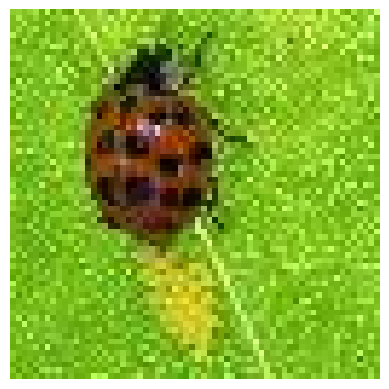

In [4]:
from PIL import Image
import torchvision.transforms as transforms
# Replace this with your actual image path
image_path = "tiny-imagenet-200/val/images/val_105.JPEG"

# Load the image
image = Image.open(image_path)

# Display the image
plt.imshow(image)
plt.axis("off")  # Turn off axis for better visualization
plt.show()


In [5]:
# Preprocess the image (use the same transformations as during training)
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

image = Image.open(image_path).convert("RGB")
input_tensor = transform(image).unsqueeze(0).to(device)  # Add batch dimension

## Build a ViT classifier

In [6]:
PATCH_SIZE = 8
EMBED_DIM = 768
prefix = "untrained_"

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

import torch
import torch.nn as nn
import torch.nn.functional as F

class MultiheadSelfAttention(nn.Module):
    def __init__(self, embed_dim, num_heads):
        super(MultiheadSelfAttention, self).__init__()
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        assert self.head_dim * num_heads == embed_dim, "embed_dim must be divisible by num_heads"

        # Linear layers for query, key, and value
        self.q_proj = nn.Linear(embed_dim, embed_dim)
        self.k_proj = nn.Linear(embed_dim, embed_dim)
        self.v_proj = nn.Linear(embed_dim, embed_dim)
        self.out_proj = nn.Linear(embed_dim, embed_dim)

    def forward(self, x):
        batch_size, num_tokens, embed_dim = x.size()
        
        # Project input to queries, keys, and values and reshape for multi-head attention
        q = self.q_proj(x).reshape(batch_size, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        k = self.k_proj(x).reshape(batch_size, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        v = self.v_proj(x).reshape(batch_size, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)

        # Calculate attention scores with scaled dot-product
        attn_scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        attn_weights = F.softmax(attn_scores, dim=-1)  # Shape: [batch, num_heads, num_tokens, num_tokens]

        # Weighted sum of values
        attn_output = torch.matmul(attn_weights, v)  # Shape: [batch, num_heads, num_tokens, head_dim]
        attn_output = attn_output.transpose(1, 2).reshape(batch_size, num_tokens, embed_dim)  # Concatenate heads
        output = self.out_proj(attn_output)

        return output, attn_weights  # Return both output and attention scores
        
class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, mlp_ratio=4.0, dropout=0.1):
        super(TransformerBlock, self).__init__()
        self.attention = MultiheadSelfAttention(embed_dim, num_heads)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, int(embed_dim * mlp_ratio)),
            nn.GELU(),
            nn.Linear(int(embed_dim * mlp_ratio), embed_dim),
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # Attention and Residual Connection
        attn_output, attn_weights = self.attention(self.norm1(x))
        x = x + self.dropout(attn_output)

        # Feed-forward Network and Residual Connection
        x = x + self.dropout(self.mlp(self.norm2(x)))
        return x, attn_weights  # Return attention weights for each block

class VisionTransformer(nn.Module):
    def __init__(self, img_size=224, patch_size=16, embed_dim=768, num_layers=12, num_heads=12, num_classes=1000):
        super(VisionTransformer, self).__init__()
        self.patch_size = patch_size
        num_patches = (img_size // patch_size) ** 2
        self.embed_dim = embed_dim
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embedding = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        
        self.patch_embed = nn.Conv2d(3, embed_dim, kernel_size=patch_size, stride=patch_size)
        self.transformer_blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads) for _ in range(num_layers)
        ])
        self.norm = nn.LayerNorm(embed_dim)
        self.fc = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        # Patch Embedding
        x = self.patch_embed(x).flatten(2).transpose(1, 2)
        
        # Add CLS token and position embeddings
        cls_tokens = self.cls_token.expand(x.size(0), -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x = x + self.pos_embedding
        
        # Transformer blocks with attention scores
        attn_weights_all = []
        for block in self.transformer_blocks:
            x, attn_weights = block(x)
            attn_weights_all.append(attn_weights)  # Collect attention scores per block
            
        x = self.norm(x)
        return self.fc(x[:, 0]), attn_weights_all  # Return both class logits and attention scores

In [8]:
model = VisionTransformer(img_size=RESOLUTION, patch_size=PATCH_SIZE, embed_dim=EMBED_DIM, num_layers=6, num_heads=12, num_classes=200)
model.cuda()

VisionTransformer(
  (patch_embed): Conv2d(3, 768, kernel_size=(8, 8), stride=(8, 8))
  (transformer_blocks): ModuleList(
    (0-5): 6 x TransformerBlock(
      (attention): MultiheadSelfAttention(
        (q_proj): Linear(in_features=768, out_features=768, bias=True)
        (k_proj): Linear(in_features=768, out_features=768, bias=True)
        (v_proj): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
      )
      (norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (mlp): Sequential(
        (0): Linear(in_features=768, out_features=3072, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=3072, out_features=768, bias=True)
      )
      (dropout): Dropout(p=0.1, inplace=False)
    )
  )
  (norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  (fc): Linear(in_features=768, out_features

In [9]:
# Make a prediction
with torch.no_grad():
    outputs, attn_weights_all = model(input_tensor)  # Get model output, ignore attention weights
    _, predicted_class = torch.max(outputs, 1)

# Map the predicted class index to a human-readable label
predicted_label = tiny_imagenet_labels[predicted_class.item()]
print(f"Predicted label: {predicted_label}")
# Access attention weights for any layer, e.g., layer 0
print("Attention scores for layer 0:", attn_weights_all[0].shape)  # Shape: [num_heads, num_patches, num_patches]

Predicted label: goldfish, Carassius auratus
Attention scores for layer 0: torch.Size([1, 12, 65, 65])


#### Train

In [13]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Define transformations for training and validation
transform_train = transforms.Compose([
    transforms.RandomResizedCrop(64),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

transform_val = transforms.Compose([
    transforms.Resize(64),
    transforms.CenterCrop(64),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Load the dataset
train_data = datasets.ImageFolder(root='tiny-imagenet-200/train', transform=transform_train)
val_data = datasets.ImageFolder(root='tiny-imagenet-200/val', transform=transform_val)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True, num_workers=4)
val_loader = DataLoader(val_data, batch_size=64, shuffle=False, num_workers=4)

In [14]:
import torch.nn as nn
import torch.optim as optim

model = VisionTransformer(img_size=RESOLUTION, patch_size=PATCH_SIZE, embed_dim=EMBED_DIM, num_layers=6, num_heads=12, num_classes=200)
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=2e-4)

In [15]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass
        outputs, _ = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Track statistics
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total
    return epoch_loss, epoch_accuracy

def validate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs, _ = model(images)
            loss = criterion(outputs, labels)
            
            # Track statistics
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total
    return epoch_loss, epoch_accuracy

In [16]:
epoch = 0

In [ ]:
num_epochs = 50
best_accuracy = 0.0
prefix = 'trained_'

for epoch in range(epoch, num_epochs):
    train_loss, train_accuracy = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_accuracy = validate(model, val_loader, criterion, device)
    
    print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.4f}, "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.4f}")

    # Optionally, save the model if validation accuracy improves
    if val_accuracy > best_accuracy:
        best_accuracy = val_accuracy
        torch.save(model.state_dict(), "best_vit_tinyimagenet.pth")

    if (epoch+1) % 10 == 0:
        torch.save(model.state_dict(), f"best_vit_tinyimagenet_{epoch+1}.pth")

Epoch [1/50] - Train Loss: 4.7049, Train Acc: 0.0590, Val Loss: 7.0445, Val Acc: 0.0100
Epoch [2/50] - Train Loss: 4.2356, Train Acc: 0.1141, Val Loss: 7.8954, Val Acc: 0.0037
Epoch [3/50] - Train Loss: 4.0245, Train Acc: 0.1447, Val Loss: 7.9901, Val Acc: 0.0086
Epoch [4/50] - Train Loss: 3.8893, Train Acc: 0.1614, Val Loss: 8.5712, Val Acc: 0.0069
Epoch [5/50] - Train Loss: 3.7686, Train Acc: 0.1817, Val Loss: 8.4722, Val Acc: 0.0053


#### Done Training...

In [12]:
# Load the trained model
# model = VisionTransformer(img_size=RESOLUTION, patch_size=PATCH_SIZE, embed_dim=EMBED_DIM, num_layers=6, num_heads=12, num_classes=200)
model = VisionTransformer(img_size=64, patch_size=8, embed_dim=256, num_layers=6, num_heads=8, num_classes=200)
model.to(device)
model.load_state_dict(torch.load("best_vit_tinyimagenet_50.pth"))
model.eval()
prefix = 'trained_'

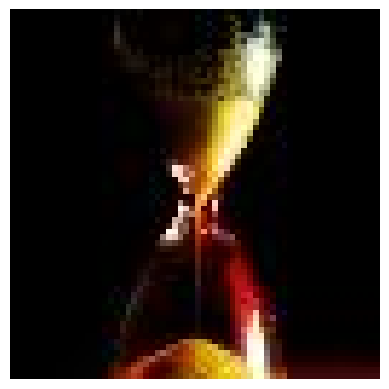

In [18]:
from PIL import Image
import torchvision.transforms as transforms
# Replace this with your actual image path
image_path = "tiny-imagenet-200/val/images/val_320.JPEG"
# image_path = "/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/notebooks/tiny-imagenet-200/train/n02509815/images/n02509815_9.JPEG"

# Load the image
image = Image.open(image_path)

# Display the image
plt.imshow(image)
plt.axis("off")  # Turn off axis for better visualization
plt.show()
# print(class_name_mapping[image_path.split('/')[-3]])

In [19]:
image = Image.open(image_path).convert("RGB")
input_tensor = transform(image).unsqueeze(0).to(device)  # Add batch dimension

In [20]:
# Make a prediction
with torch.no_grad():
    outputs, attn_weights_all = model(input_tensor)  # Get model output, ignore attention weights
    _, predicted_class = torch.max(outputs, 1)
print(predicted_class)
# Map the predicted class index to a human-readable label
predicted_label = tiny_imagenet_labels[predicted_class.item()]
print(f"Predicted label: {predicted_label}")
# Access attention weights for any layer, e.g., layer 0
print("Attention scores for layer 0:", attn_weights_all[0].shape)  # Shape: [num_heads, num_patches, num_patches]

tensor([163], device='cuda:0')
Predicted label: go-kart
Attention scores for layer 0: torch.Size([1, 8, 65, 65])


### Explore Interpretation Visualization

In [68]:
def split_prediction_and_attention_scores(outputs, attention_scores=None):
    # Standard classification predictions
    predictions = outputs

    # Organize attention scores if provided
    attention_score_dict = {}
    if attention_scores:
        for i, score in enumerate(attention_scores):
            attention_score_dict[f"layer_{i}"] = score.cpu()
    return predictions, attention_score_dict

In [69]:
with torch.no_grad():
    outputs, attention_scores = model(input_tensor)
    predictions, attention_score_dict = split_prediction_and_attention_scores(outputs, attention_scores)


#### Mean Attention Distance

In [70]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def compute_distance_matrix(patch_size, num_patches, length):
    distance_matrix = torch.zeros((num_patches, num_patches))
    for i in range(num_patches):
        for j in range(num_patches):
            if i == j:  # zero distance
                continue
            xi, yi = int(i / length), i % length
            xj, yj = int(j / length), j % length
            distance_matrix[i, j] = patch_size * np.linalg.norm(torch.tensor([xi - xj, yi - yj]))
    return distance_matrix

def compute_mean_attention_dist(patch_size, attention_weights, model_type):
    num_cls_tokens = 1

    # Remove the CLS token attention (if any)
    attention_weights = attention_weights[..., num_cls_tokens:, num_cls_tokens:]
    num_patches = attention_weights.shape[-1]
    length = int(np.sqrt(num_patches))
    assert length**2 == num_patches, "Num patches is not a perfect square"

    # Compute distance matrix
    distance_matrix = compute_distance_matrix(patch_size, num_patches, length).unsqueeze(0).unsqueeze(0)
    # The attention_weights along the last axis adds to 1
    # this is due to the fact that they are softmax of the raw logits
    # summation of the (attention_weights * distance_matrix)
    # should result in an average distance per token.
    mean_distances = attention_weights * distance_matrix
    mean_distances = torch.sum(mean_distances, dim=-1) # Sum along last axis to get average distance per token
    mean_distances = torch.mean(mean_distances, dim=-1) # Now average across all the tokens

    return mean_distances

In [71]:
# Build mean distances for each Transformer block
mean_distances = {
    f"{name}_mean_dist": compute_mean_attention_dist(
        patch_size=PATCH_SIZE,
        attention_weights=attention_weight[0],
        model_type="original_vit",
    )
    for name, attention_weight in attention_score_dict.items()
}

# Determine the number of heads from one of the distance outputs
num_heads = mean_distances["layer_0_mean_dist"].shape[-1]
print(f"Num Heads: {num_heads}.")

Num Heads: 8.


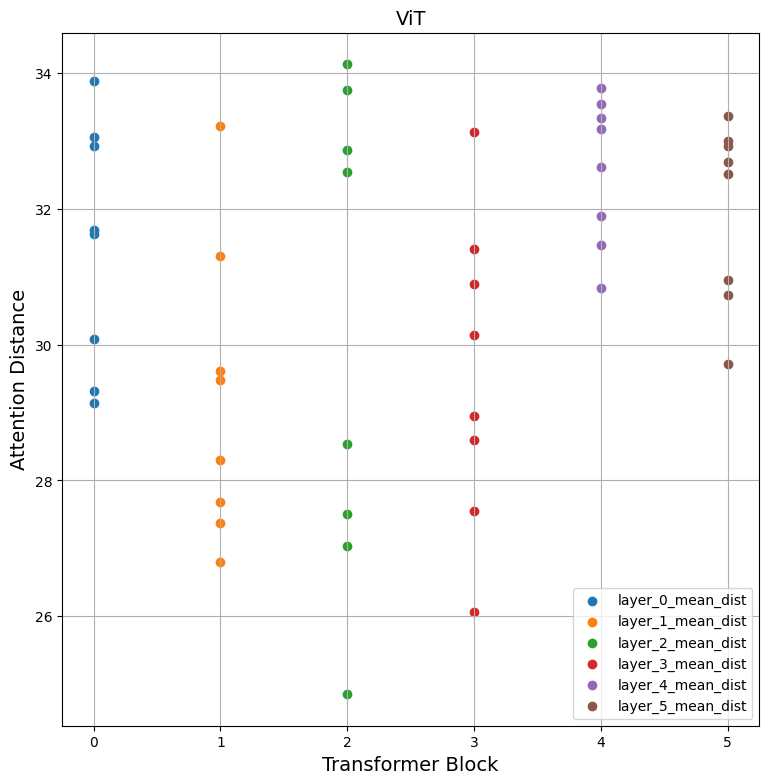

In [72]:
# Plotting mean distances per Transformer block
plt.figure(figsize=(9, 9))
for idx, (name, mean_distance) in enumerate(mean_distances.items()):
    x = [idx] * num_heads
    y = mean_distance[0, :].cpu().numpy()
    plt.scatter(x=x, y=y, label=name)

plt.legend(loc="lower right")
plt.xlabel("Transformer Block", fontsize=14)
plt.ylabel("Attention Distance", fontsize=14)
plt.title("ViT", fontsize=14)
plt.grid()
# plt.show()
plt.savefig(prefix+'mean_dist')

#### Attention Rollout

In [73]:
import torch
import cv2
import numpy as np

def attention_rollout_map(image, attention_score_dict, model_type):
    num_cls_tokens = 1

    # Stack attention matrices from Transformer blocks
    attn_mat = torch.stack([attention_score_dict[k] for k in attention_score_dict.keys()])  # Shape: [layers, batch, heads, tokens, tokens]
    attn_mat = attn_mat.squeeze(1)  # Remove batch dimension if unnecessary
    
    # Average the attention weights across all heads
    attn_mat = attn_mat.mean(dim=1)  # Shape: [layers, tokens, tokens]

    # Add identity matrix to account for residual connections and normalize
    residual_attn = torch.eye(attn_mat.size(-1), device=attn_mat.device)
    aug_attn_mat = attn_mat + residual_attn
    aug_attn_mat = aug_attn_mat / aug_attn_mat.sum(dim=-1, keepdim=True)

    # Move to numpy for joint multiplication
    aug_attn_mat = aug_attn_mat.cpu().numpy()
    
    # Recursive multiplication of attention matrices
    joint_attentions = np.zeros_like(aug_attn_mat)
    joint_attentions[0] = aug_attn_mat[0]
    for n in range(1, aug_attn_mat.shape[0]):
        joint_attentions[n] = np.matmul(aug_attn_mat[n], joint_attentions[n - 1])

    # Extract attention from the final layer (output token to input space)
    v = joint_attentions[-1]
    grid_size = int(np.sqrt(v.shape[-1]))
    mask = v[0, num_cls_tokens:].reshape(grid_size, grid_size)
    mask = cv2.resize(mask / mask.max(), image.size)[..., np.newaxis]
    
    # Apply the attention mask to the image
    result = (mask * np.array(image)).astype("uint8")
    return result

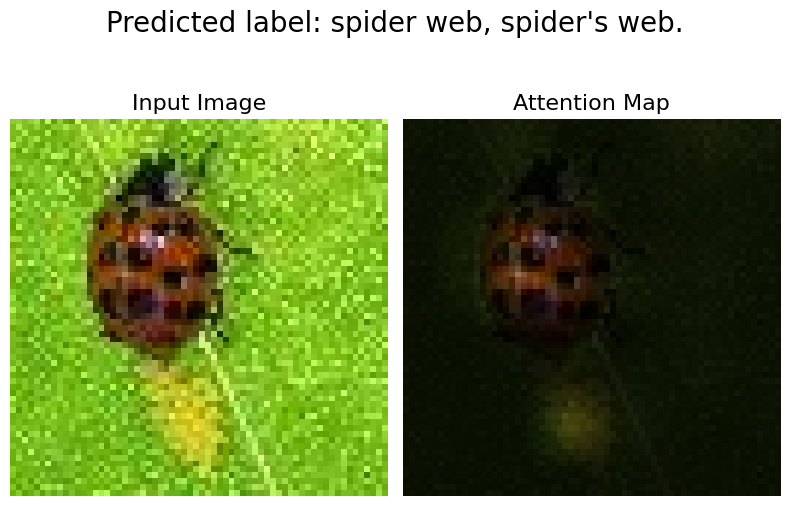

In [74]:
attn_rollout_result = attention_rollout_map(
    image, attention_score_dict, model_type="original_vit"
)

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(8, 10))
fig.suptitle(f"Predicted label: {predicted_label}.", fontsize=20)

_ = ax1.imshow(image)
_ = ax2.imshow(attn_rollout_result)
ax1.set_title("Input Image", fontsize=16)
ax2.set_title("Attention Map", fontsize=16)
ax1.axis("off")
ax2.axis("off")

fig.tight_layout()
fig.subplots_adjust(top=1.35)
# fig.show()
plt.savefig(prefix+'rollout_map')

#### Attention Heatmap

In [75]:
import torch
import torchvision.transforms.functional as TF

def attention_heatmap(attention_score_dict, image, model_type="dino"):
    num_tokens =1

    # Sort Transformer blocks by their depth
    attention_score_list = list(attention_score_dict.keys())
    attention_score_list.sort(key=lambda x: int(x.split("_")[-1]), reverse=True)

    # Calculate feature map dimensions
    w_featmap = image.size[1] // PATCH_SIZE
    h_featmap = image.size[0] // PATCH_SIZE
    attention_scores = attention_score_dict[attention_score_list[0]]
    print(attention_scores.shape)

    # Extract attention from the CLS token
    num_heads = attention_scores.shape[1]
    attentions = attention_scores[0, :, 0, num_tokens:].reshape(num_heads, -1)
    print(attentions.shape)

    # Reshape attention scores into mini patches
    attentions = attentions.reshape(num_heads, w_featmap, h_featmap)
    attentions = attentions.permute(1, 2, 0)  # Transpose to (w_featmap, h_featmap, num_heads)
    print(attentions.shape)

    # Resize the attention patches to the size of the original image
    attentions_resized = TF.resize(attentions, size=(h_featmap * PATCH_SIZE, w_featmap * PATCH_SIZE))
    print(attentions_resized.shape)
    return attentions_resized

torch.Size([1, 8, 65, 65])
torch.Size([8, 64])
torch.Size([8, 8, 8])
torch.Size([8, 64, 64])


/state/partition1/job-53510274/ipykernel_2945728/1986983045.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # Adjust layout to make room for colorbar


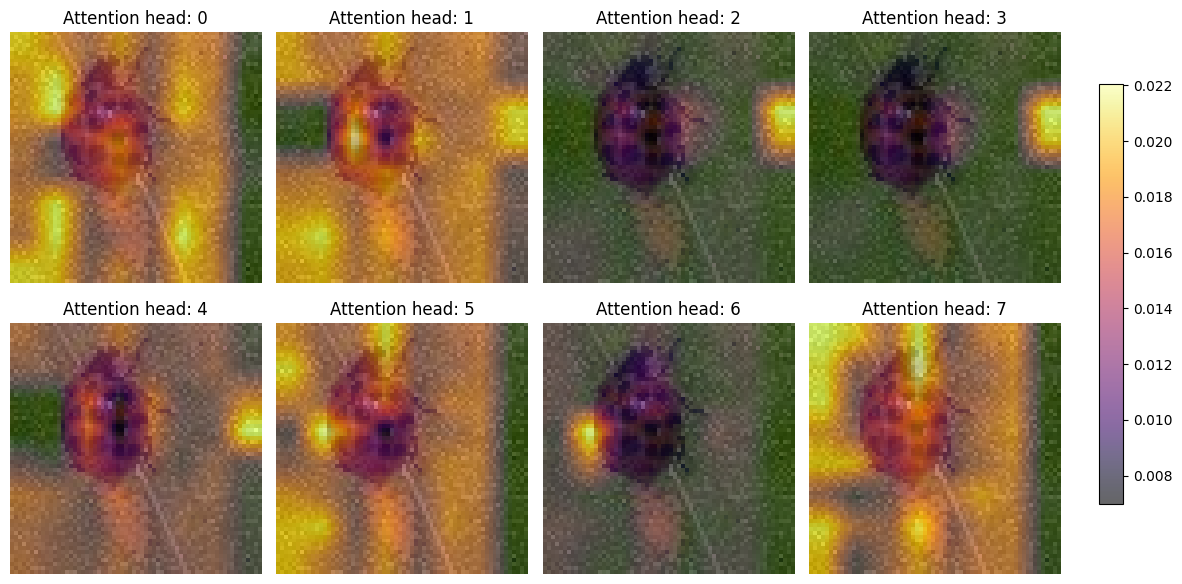

In [76]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Generate the attention heatmaps.
attentions = attention_heatmap(attention_score_dict, image)  # Assuming `attentions` has shape (num_heads, height, width)

# Plot the maps.
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(12, 6))
img_count = 0

# Plot each attention head map with a colorbar
for i in range(2):
    for j in range(4):
        if img_count < attentions.shape[-1]:  # Ensure we do not exceed the number of attention heads
            ax = axes[i, j]
            img = ax.imshow(image)
            heatmap = ax.imshow(attentions[img_count].cpu().numpy(), cmap="inferno", alpha=0.6)

            ax.title.set_text(f"Attention head: {img_count}")
            ax.axis("off")
            img_count += 1

# Create a single colorbar for all subplots
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # Position for the colorbar
fig.colorbar(heatmap, cax=cbar_ax, orientation="vertical")

plt.tight_layout(rect=[0, 0, 0.9, 1])  # Adjust layout to make room for colorbar
# plt.show()
plt.savefig(prefix+'attention_heatmap')

#### Learned Projections

(256, 3, 8, 8)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


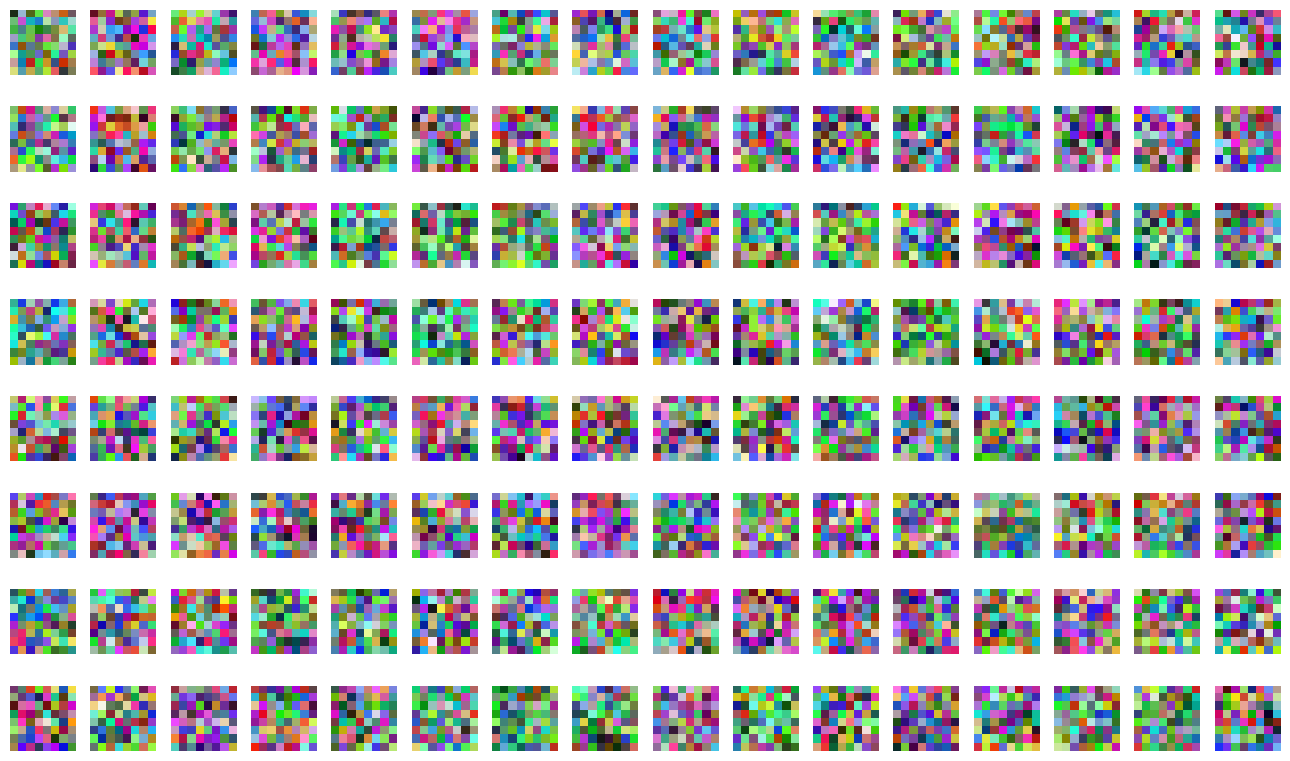

In [77]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import MinMaxScaler

def extract_weights(model, name):
    # Extract weights for the specified layer
    for param_name, param in model.state_dict().items():
        if param_name.startswith(name):
            return param.cpu().numpy()
    return None

# Assume `vit_base_i21k_patch16_224` is your Vision Transformer model in PyTorch
# Replace `"conv_projection/kernel"` with the specific layer name you want to extract
projections = extract_weights(model, "patch_embed")  # Adjust based on your layer naming
print(projections.shape)

# Check if the projections were successfully extracted
if projections is None:
    print("Layer not found in model.")
else:
    projections = projections.transpose(2, 3, 1, 0)
    projection_dim = projections.shape[-1]  # Assuming [out_channels, in_channels, kernel_h, kernel_w]
    patch_h, patch_w, patch_channels = projections.shape[:-1]

    # Scale the projections.
    scaled_projections = MinMaxScaler().fit_transform(
        projections.reshape(-1, projection_dim)
    )
    
    # Reshape the scaled projections so that the leading
    # Three dimensions resemble an image.
    scaled_projections = scaled_projections.reshape(patch_h, patch_w, patch_channels, -1)
    
    # Visualize the first 128 filters of the learned
    # projections.
    fig, axes = plt.subplots(nrows=8, ncols=16, figsize=(13, 8))
    img_count = 0
    limit = 128
    
    for i in range(8):
        for j in range(16):
            if img_count < limit:
                axes[i, j].imshow(scaled_projections[..., img_count])
                axes[i, j].axis("off")
                img_count += 1
    
    fig.tight_layout()
    # plt.show()
    plt.savefig(prefix+'projection_filters')

#### Learned Positional embeddings

(64, 256)


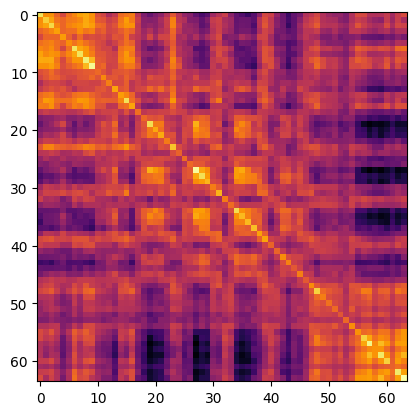

In [78]:
position_embeddings = extract_weights(model, "pos_embedding")

# Discard the batch dimension and the position embeddings of the
# cls token.
position_embeddings = position_embeddings.squeeze()[1:, ...]
print(position_embeddings.shape)

similarity = position_embeddings @ position_embeddings.T
plt.imshow(similarity, cmap="inferno")
# plt.show()
plt.savefig(prefix+'positional_embeddings')

## Build a SOTA Swin transformer classifier

### Explore Interpretation Visualization

## Build Climate Swin Arch

### Explore Interpretation Visualization